In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
os.environ['OMP_NUM_THREADS'] = '1'  # Ép chạy 1 luồng duy nhất

import sys
from pathlib import Path
import numpy as np
import pandas as pd

PROJECT_ROOT = Path('../').resolve()
sys.path.append(str(PROJECT_ROOT))

print('PROJECT_ROOT:', PROJECT_ROOT)

from src.utils.utils import load_csv
from src.models.train_xgboost import XGBoostTrainer

from src.config import (
    TRAIN_LABEL_PATH,
    FINAL_TRAIN_SBERT_PATH,
    FINAL_TEST_SBERT_PATH,
    SUBMISSION_XGBOOST_PATH,
    CLEANED_TEST_PATH,
)

PROJECT_ROOT: /Users/nhatnam/Documents/DM_252/Assignment


In [2]:
print('Loading SBERT train features...')
X_train = np.load(FINAL_TRAIN_SBERT_PATH)
print(f'  X_train shape: {X_train.shape}')

print('Loading SBERT test features...')
X_test = np.load(FINAL_TEST_SBERT_PATH)
print(f'  X_test  shape: {X_test.shape}')

label_df = load_csv(TRAIN_LABEL_PATH)
print(label_df.head())
print('Label columns:', label_df.columns.tolist())

y_train = label_df.values.ravel()
y_train = y_train - 1  # XGBoost yêu cầu nhãn bắt đầu từ 0
print(f'y_train shape : {y_train.shape}')
print(f'Classes       : {np.unique(y_train)}')
print(f'Distribution  :\n{pd.Series(y_train).value_counts().sort_index()}')

Loading SBERT train features...
  X_train shape: (510, 392)
Loading SBERT test features...
  X_test  shape: (86, 392)
   0
0  1
1  5
2  1
3  5
4  1
Label columns: ['0']
y_train shape : (510,)
Classes       : [0 1 2 3 4]
Distribution  :
0    130
1    103
2     85
3     89
4    103
Name: count, dtype: int64


In [3]:
assert X_train.shape[0] == len(y_train), (
    f'Mismatch: X_train has {X_train.shape[0]} rows, y_train has {len(y_train)} rows'
)
print('Sanity check passed!')

Sanity check passed!


In [4]:
NUM_CLASS = len(np.unique(y_train))
print(f'Số class: {NUM_CLASS}')

xgb_params = {
    'objective'        : 'multi:softprob',
    'num_class'        : NUM_CLASS,
    'eval_metric'      : 'mlogloss',
    'verbosity'        : 0,
    'booster'          : 'gbtree',
    'learning_rate'    : 0.05,
    'max_depth'        : 6,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 0.1,
    'seed'             : 42,
}

trainer = XGBoostTrainer(params=xgb_params)

Số class: 5


In [5]:
macro_f1 = trainer.train(X_train, y_train, n_splits=5)
print(f'\nCV Macro F1 (OOF): {macro_f1:.4f}')


Overall Macro F1: 0.2715

CV Macro F1 (OOF): 0.2715


In [6]:
test_preds = trainer.predict(X_test)
print(f'test_preds shape : {test_preds.shape}')
print(f'Predicted classes: {np.unique(test_preds)}')

test_preds shape : (86,)
Predicted classes: [0 1 2 3 4]


In [12]:

test_df = load_csv(CLEANED_TEST_PATH)
print(test_df.head())
print('Test columns:', test_df.columns.tolist())

ID_COL = 'id'
LABEL_COL = 'Label'

submission = pd.DataFrame({
    ID_COL  : test_df[ID_COL].values,
    LABEL_COL: test_preds + 1,
})
    
print(submission.head(10))
print(f'\nSubmission shape: {submission.shape}')


os.makedirs(Path(SUBMISSION_XGBOOST_PATH).parent, exist_ok=True)

submission.to_csv(SUBMISSION_XGBOOST_PATH, index=False)
print(f'Submission saved to: {SUBMISSION_XGBOOST_PATH}')



                                               title venue  year  \
0  research summary on implementing functional pa...  iclp  2020   
1          reasoning in highly reactive environments  iclp  2019   
2  logic programming with max-clique and its appl...  iclp  2017   
3  establish coherence in logic programs modellin...  iclp  2021   
4  answer set programming for qualitative spatio-...  iclp  2016   

                       authors                        doi   id  \
0                  finn teegen       10.4204/eptcs.325.39  498   
1            francesco pacenza       10.4204/eptcs.306.57  255   
2  igor dukanovic, franz rendl  10.1007/s10107-006-0026-z  570   
3     kewen wang, huowang chen         10.1007/bfb0054794   93   
4             jason jingshi li      10.1109/ictai.2012.87  548   

                                            abstract  
0  in this research summary we present our recent...  
1  the aim of my ph d thesis concerns reasoning i...  
2  the semidefinite programmi

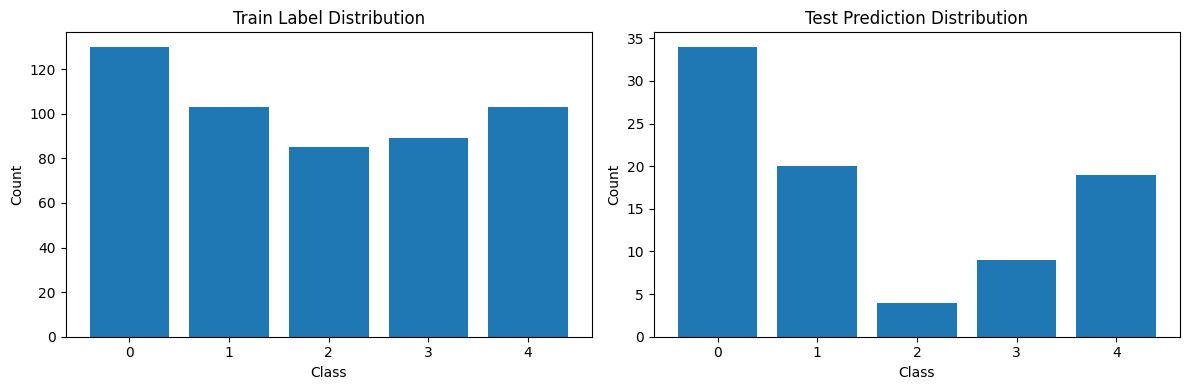

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Train label distribution
axes[0].bar(*np.unique(y_train, return_counts=True))
axes[0].set_title('Train Label Distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

# Test prediction distribution
axes[1].bar(*np.unique(test_preds, return_counts=True))
axes[1].set_title('Test Prediction Distribution')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()